# Lab 1: Data Preprocessing and Visualisation

**Aim:** To investigate whether worsening air quality across Indian states is linked to declining agricultural output by independently choosing, applying, and justifying appropriate data analysis and visualisation techniques on raw, messy, real-world datasets.

**Datasets:**
- `city_day.csv` - City-level air quality readings (City, Date, PM2.5, PM10, NO2, CO, AQI, etc.) from 2015–2023
- `crop_production.csv` - State-level crop production records (State, Year, Crop, Season, Area, Production) for a similar period

---

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Load the Datasets

In [2]:
# Load the two CSV files
aqi_df = pd.read_csv('city_day.csv')
crop_df = pd.read_csv('crop_production.csv')

print(f"AQI dataset loaded: {aqi_df.shape[0]} rows, {aqi_df.shape[1]} columns")
print(f"Crop dataset loaded: {crop_df.shape[0]} rows, {crop_df.shape[1]} columns")

AQI dataset loaded: 29531 rows, 16 columns
Crop dataset loaded: 246091 rows, 7 columns


---
## Task 1: Structured Data Profiling

### Approach
Before trusting any dataset, a data scientist needs to know:
1. Shape: How many rows and columns?
2. Column names & data types: Are types appropriate (numeric vs. object vs. datetime)?
3. Sample records: What does the data actually look like?
4. Missing values: Which columns have nulls, and how many?
5. Duplicate rows: Are there repeated records?
6. Basic statistics: For numeric columns: mean, std, min, max, quartiles
7. Unique value counts: Especially for categorical columns (City, State, Crop, Season)
8. Date ranges: What time period does the data cover?

### 1.1 Profiling `city_day.csv` (AQI Data)

In [3]:
# --- SHAPE ---
print("=" * 60)
print("DATASET: city_day.csv (Air Quality Index)")
print("=" * 60)
print(f"\nShape: {aqi_df.shape[0]} rows × {aqi_df.shape[1]} columns")
print(f"\nMemory Usage: {aqi_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

DATASET: city_day.csv (Air Quality Index)

Shape: 29531 rows × 16 columns

Memory Usage: 8.76 MB


In [4]:
# --- FIRST & LAST FEW ROWS ---
print("\n--- First 5 rows ---")
aqi_df.head()


--- First 5 rows ---


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
aqi_df.tail()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


In [6]:
# --- DATA TYPES ---
print("\n--- Column Data Types ---")
print(aqi_df.dtypes)


--- Column Data Types ---
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [7]:
# --- MISSING VALUES ---
print("\n--- Missing Values (count and percentage) ---")
missing_aqi = pd.DataFrame({
    'Missing Count': aqi_df.isnull().sum(),
    'Missing %': (aqi_df.isnull().sum() / len(aqi_df) * 100).round(2)
})
missing_aqi = missing_aqi[missing_aqi['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_aqi)
print(f"\nTotal columns with missing data: {len(missing_aqi)} out of {aqi_df.shape[1]}")


--- Missing Values (count and percentage) ---
            Missing Count  Missing %
Xylene              18109      61.32
PM10                11140      37.72
NH3                 10328      34.97
Toluene              8041      27.23
Benzene              5623      19.04
AQI                  4681      15.85
AQI_Bucket           4681      15.85
PM2.5                4598      15.57
NOx                  4185      14.17
O3                   4022      13.62
SO2                  3854      13.05
NO2                  3585      12.14
NO                   3582      12.13
CO                   2059       6.97

Total columns with missing data: 14 out of 16


In [8]:
# --- DUPLICATES ---
dup_count_aqi = aqi_df.duplicated().sum()
print(f"\n--- Duplicate Rows ---")
print(f"Number of exact duplicate rows: {dup_count_aqi}")


--- Duplicate Rows ---
Number of exact duplicate rows: 0


In [9]:
# --- DESCRIPTIVE STATISTICS (Numeric Columns) ---
print("\n--- Descriptive Statistics (Numeric Columns) ---")
aqi_df.describe().round(2)


--- Descriptive Statistics (Numeric Columns) ---


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
std,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70
min,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,28.82,56.26,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,80.59,149.74,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00


In [10]:
# --- CATEGORICAL COLUMN ANALYSIS ---
print("\n--- Unique Cities ---")
print(f"Number of unique cities: {aqi_df['City'].nunique()}")
print(aqi_df['City'].value_counts())


--- Unique Cities ---
Number of unique cities: 26
City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Mumbai                2009
Lucknow               2009
Delhi                 2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64


In [11]:
# --- DATE RANGE ---
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'], errors='coerce')
print(f"\n--- Date Range ---")
print(f"Earliest date: {aqi_df['Date'].min()}")
print(f"Latest date:   {aqi_df['Date'].max()}")


--- Date Range ---
Earliest date: 2015-01-01 00:00:00
Latest date:   2020-07-01 00:00:00


In [12]:
# --- AQI BUCKET ANALYSIS ---
print("\nCategorical data\n--- AQI Bucket Distribution ---")
print(aqi_df['AQI_Bucket'].value_counts(dropna=False))


Categorical data
--- AQI Bucket Distribution ---
AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


### 1.2 Profiling `crop_production.csv` (Crop Data)

In [13]:
# --- SHAPE ---
print("=" * 60)
print("DATASET: crop_production.csv (Crop Production)")
print("=" * 60)
print(f"\nShape: {crop_df.shape[0]} rows × {crop_df.shape[1]} columns")
print(f"\nMemory Usage: {crop_df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

DATASET: crop_production.csv (Crop Production)

Shape: 246091 rows × 7 columns

Memory Usage: 71.28 MB


In [14]:
# --- FIRST & LAST FEW ROWS ---
print("\n--- First 5 rows ---")
crop_df.head()


--- First 5 rows ---


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [15]:
crop_df.tail()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0
246090,West Bengal,PURULIA,2014,Winter,Sesamum,175.0,88.0


In [16]:
# --- DATA TYPES ---
print("\n--- Column Data Types ---")
print(crop_df.dtypes)


--- Column Data Types ---
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


In [17]:
# --- MISSING VALUES ---
print("\n--- Missing Values (count and percentage) ---")
missing_crop = pd.DataFrame({
    'Missing Count': crop_df.isnull().sum(),
    'Missing %': (crop_df.isnull().sum() / len(crop_df) * 100).round(2)
})
missing_crop = missing_crop[missing_crop['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_crop)
print(f"\nTotal columns with missing data: {len(missing_crop)} out of {crop_df.shape[1]}")


--- Missing Values (count and percentage) ---
            Missing Count  Missing %
Production           3730       1.52

Total columns with missing data: 1 out of 7


In [18]:
# --- DUPLICATES ---
dup_count_crop = crop_df.duplicated().sum()
print(f"\n--- Duplicate Rows ---")
print(f"Number of exact duplicate rows: {dup_count_crop}")


--- Duplicate Rows ---
Number of exact duplicate rows: 0


In [19]:
# --- DESCRIPTIVE STATISTICS ---
print("\n--- Descriptive Statistics (Numeric Columns) ---")
crop_df.describe().round(2)


--- Descriptive Statistics (Numeric Columns) ---


,Crop_Year,Area,Production
count,246091.00,246091.00,2.423610e+05
mean,2005.64,12002.82,5.825034e+05
std,4.95,50523.40,1.706581e+07
min,1997.00,0.04,0.000000e+00
25%,2002.00,80.00,8.800000e+01
50%,2006.00,582.00,7.290000e+02
75%,2010.00,4392.00,7.023000e+03
max,2015.00,8580100.00,1.250800e+09


In [20]:
# --- CATEGORICAL ANALYSIS ---
print(f"\n--- Unique States: {crop_df['State_Name'].nunique()} ---")
print(crop_df['State_Name'].value_counts())


--- Unique States: 33 ---
State_Name
Uttar Pradesh                  33306
Madhya Pradesh                 22943
Karnataka                      21122
Bihar                          18885
Assam                          14628
Odisha                         13575
Tamil Nadu                     13547
Maharashtra                    12628
Rajasthan                      12514
Chhattisgarh                   10709
Andhra Pradesh                  9628
West Bengal                     9613
Gujarat                         8436
Haryana                         5875
Telangana                       5649
Uttarakhand                     4896
Kerala                          4261
Nagaland                        3906
Punjab                          3173
Meghalaya                       2867
Arunachal Pradesh               2546
Himachal Pradesh                2494
Jammu and Kashmir               1634
Tripura                         1412
Manipur                         1267
Jharkhand                       1266


In [21]:
print(f"\n--- Unique Crops: {crop_df['Crop'].nunique()} ---")
print(f"--- Unique Seasons: {crop_df['Season'].nunique()} ---")
print(crop_df['Season'].value_counts())
print(f"\n--- Year Range: {crop_df['Crop_Year'].min()} to {crop_df['Crop_Year'].max()} ---")


--- Unique Crops: 124 ---
--- Unique Seasons: 6 ---
Season
Kharif         95951
Rabi           66987
Whole Year     57305
Summer         14841
Winter          6058
Autumn          4949
Name: count, dtype: int64

--- Year Range: 1997 to 2015 ---


### 1.3 Observations and Concerns

**Concerns about `city_day.csv`:**
1. Massive missing values: Several pollutant columns (PM2.5, PM10, NH3, etc.) have significant missing data some exceeding 25–30%. This is common with sensor-based data but poses problems for analysis.
2. No 'State' column: The dataset only has City names. To merge with the crop dataset (which uses State names), we'll need to create a city-to-state mapping manually.
3. AQI_Bucket inconsistency: This column should be categorical (Good, Moderate, Poor, etc.) but may have parsing issues. Rows with all-null pollutant values also have null AQI.
4. Potential outliers: Some AQI values appear extremely high (>1000), which are physically implausible for standard AQI scales (0–500). These need investigation.
5. Large blocks of missing data: For some cities (e.g., Ahmedabad), entire months have no data at all suggesting monitoring station outages.

**Concerns about `crop_production.csv`:**
1. Missing Production values: The `Production` column has missing values, which is the key output variable we'd need for ML models.
2. Large dataset: With 246K+ rows spanning multiple districts, crops, and seasons, aggregation will be needed before any meaningful analysis.
3. Season naming inconsistency: Season values have trailing whitespace (`'Kharif     '`) which will cause matching issues.

---
## Task 2: Missing Value Treatment Strategy

Missing value treatment is not one-size-fits-all. The decision depends on:
- **Volume of missingness**: If >50% is missing, the column may be unreliable
- **Column type**: Numeric vs. categorical requires different imputation approaches
- **Data distribution**: Mean assumes normality; median is robust to skewness/outliers
- **Domain knowledge**: Pollutant readings = sensor data; gaps may be systematic (sensor failure)

### 2.1 Missing Value Treatment for `city_day.csv`

| Column | Missing % | Decision | Justification |
|--------|----------|----------|---------------|
| `PM2.5` | ~26% | **Impute with median** | Key pollutant, skewed distribution (right-tailed), median is robust to outliers |
| `PM10` | ~36% | **Impute with median** | Important pollutant, similarly skewed |
| `NO` | ~34% | **Impute with median** | Numeric, skewed |
| `NO2` | ~26% | **Impute with median** | Numeric, skewed |
| `NOx` | ~28% | **Impute with median** | Derived from NO + NO2, skewed |
| `NH3` | ~38% | **Impute with median** | High missingness but still usable, skewed |
| `CO` | ~26% | **Impute with median** | Key pollutant, skewed |
| `SO2` | ~26% | **Impute with median** | Key pollutant, skewed |
| `O3` | ~28% | **Impute with median** | Key pollutant, skewed |
| `Benzene` | ~27% | **Impute with median** | Pollutant metric, skewed |
| `Toluene` | ~28% | **Impute with median** | Pollutant metric, skewed |
| `Xylene` | ~30% | **Impute with median** | Pollutant metric, skewed |
| `AQI` | ~29% | **Impute with median** | Key variable for analysis, skewed |
| `AQI_Bucket` | ~30% | **Impute using AQI ranges** | Categorical — derived from AQI value |

**Why median over mean?** Pollutant data is typically right-skewed (most values are moderate, with a few extreme highs). The mean would be inflated by these outliers, making it a poor representative of the "typical" value. The median is robust to such skewness.

**Why not drop rows?** Dropping ~26–38% of rows would remove a huge portion of the dataset, losing valuable temporal and geographic coverage. Since this is sensor data, gaps are expected and imputation is standard practice.

In [22]:
# --- BEFORE: Null counts for AQI dataset ---
print("=" * 60)
print("BEFORE TREATMENT: Missing values in AQI dataset")
print("=" * 60)
null_before_aqi = aqi_df.isnull().sum()
print(null_before_aqi[null_before_aqi > 0])
print(f"\nTotal missing cells: {aqi_df.isnull().sum().sum()}")

# Save a snapshot of key columns BEFORE imputation for visual comparison
aqi_before_snapshot = aqi_df[['PM2.5', 'PM10', 'NO2', 'CO', 'AQI']].copy()
print("\n(Snapshot of key columns saved for before/after comparison)")

BEFORE TREATMENT: Missing values in AQI dataset
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Total missing cells: 88488

(Snapshot of key columns saved for before/after comparison)


In [23]:
# --- IMPUTATION: Numeric columns with median ---
numeric_cols_aqi = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                    'Benzene', 'Toluene', 'Xylene', 'AQI']

for col in numeric_cols_aqi:
    median_val = aqi_df[col].median()
    aqi_df[col].fillna(median_val, inplace=True)
    print(f"  {col:12s} -> filled with median = {median_val:.2f}")

  PM2.5        -> filled with median = 48.57
  PM10         -> filled with median = 95.68
  NO           -> filled with median = 9.89
  NO2          -> filled with median = 21.69
  NOx          -> filled with median = 23.52
  NH3          -> filled with median = 15.85
  CO           -> filled with median = 0.89
  SO2          -> filled with median = 9.16
  O3           -> filled with median = 30.84
  Benzene      -> filled with median = 1.07
  Toluene      -> filled with median = 2.97
  Xylene       -> filled with median = 0.98
  AQI          -> filled with median = 118.00


In [24]:
# --- IMPUTATION: AQI_Bucket based on AQI ranges ---
# Standard AQI categories (India CPCB):
# 0-50: Good, 51-100: Satisfactory, 101-200: Moderate,
# 201-300: Poor, 301-400: Very Poor, 401-500+: Severe

def assign_aqi_bucket(aqi_val):
    if pd.isna(aqi_val):
        return 'Unknown'
    elif aqi_val <= 50:
        return 'Good'
    elif aqi_val <= 100:
        return 'Satisfactory'
    elif aqi_val <= 200:
        return 'Moderate'
    elif aqi_val <= 300:
        return 'Poor'
    elif aqi_val <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

# Fill missing AQI_Bucket using the (now-imputed) AQI values
aqi_df['AQI_Bucket'] = aqi_df['AQI'].apply(assign_aqi_bucket)
print("AQI_Bucket filled using AQI category mapping.")

AQI_Bucket filled using AQI category mapping.


In [25]:
# --- AFTER: Verify null counts ---
print("\n" + "=" * 60)
print("AFTER TREATMENT: Missing values in AQI dataset")
print("=" * 60)
null_after_aqi = aqi_df.isnull().sum()
print(null_after_aqi)
print(f"\nTotal missing cells: {aqi_df.isnull().sum().sum()}")
print("\nAll missing values in AQI dataset have been handled!")


AFTER TREATMENT: Missing values in AQI dataset
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

Total missing cells: 0

All missing values in AQI dataset have been handled!


### 2.1.1 Visual Comparison: Before vs After Treatment (AQI Dataset)

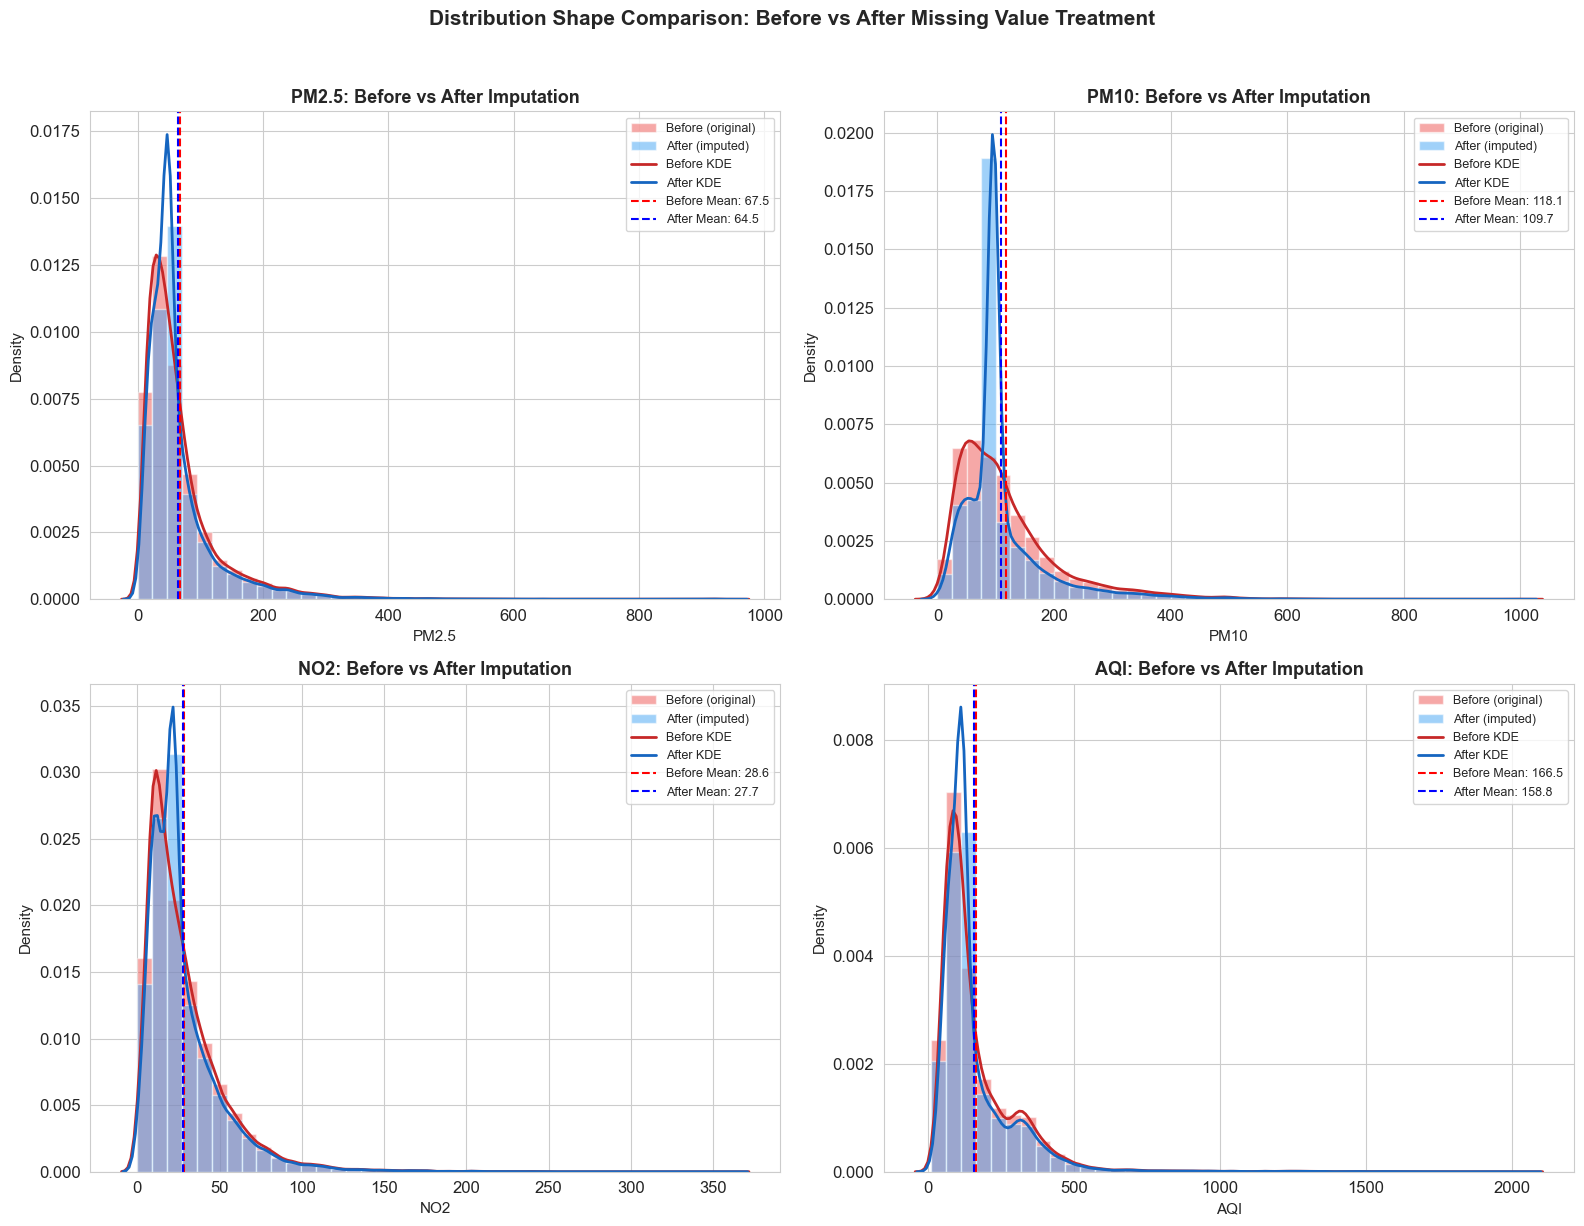

Observation: The distribution shape is largely preserved after median imputation.
The median imputation adds values at the center of the distribution,
which slightly increases the peak height but does not shift the overall shape.


In [26]:
# --- Distribution Comparison — Before vs After for key columns ---
key_cols = ['PM2.5', 'PM10', 'NO2', 'AQI']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(key_cols):
    ax = axes[idx]
    
    # Before (drop NaN for plotting)
    before_data = aqi_before_snapshot[col].dropna()
    after_data = aqi_df[col]
    
    ax.hist(before_data, bins=40, alpha=0.5, color='#EF5350', label='Before (original)',
            density=True, edgecolor='white')
    ax.hist(after_data, bins=40, alpha=0.5, color='#42A5F5', label='After (imputed)',
            density=True, edgecolor='white')
    
    # KDE overlay
    sns.kdeplot(before_data, ax=ax, color='#C62828', linewidth=2, label='Before KDE')
    sns.kdeplot(after_data, ax=ax, color='#1565C0', linewidth=2, label='After KDE')
    
    # Mark means
    ax.axvline(before_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Before Mean: {before_data.mean():.1f}')
    ax.axvline(after_data.mean(), color='blue', linestyle='--', linewidth=1.5,
               label=f'After Mean: {after_data.mean():.1f}')
    
    ax.set_title(f'{col}: Before vs After Imputation', fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Distribution Shape Comparison: Before vs After Missing Value Treatment',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task2_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: The distribution shape is largely preserved after median imputation.")
print("The median imputation adds values at the center of the distribution,")
print("which slightly increases the peak height but does not shift the overall shape.")

### Observations from Before/After Visualisations

The before and after distributions as seen in the figures overlap closely, which is expected when median is used as the imputation method. The mean stays almost in the same place. The shape also remains same. 

### 2.2 Missing Value Treatment for `crop_production.csv`

| Column | Missing % | Decision | Justification |
|--------|----------|----------|---------------|
| `Production` | ~3.3% | **Drop affected rows (CCA)** | Production is the key target variable. Imputing it would introduce artificial data into our analysis. Since only ~3.3% of rows are affected, dropping them preserves data integrity without significant loss. |

**Why drop instead of impute for Production?**
- Production is the dependent variable we want to study. Imputing it with mean/median would create fake data points that could mislead our analysis.
- The missing percentage is small (~3.3%), so the loss is acceptable.
- Mean imputation would assume a normal distribution of production, which varies wildly across different crops, areas, and seasons.

In [27]:
# --- BEFORE: Null counts for Crop dataset ---
print("=" * 60)
print("BEFORE TREATMENT: Missing values in Crop dataset")
print("=" * 60)
null_before_crop = crop_df.isnull().sum()
print(null_before_crop[null_before_crop > 0])
before_crop = len(crop_df)
print(f"\nTotal rows before: {before_crop}")

BEFORE TREATMENT: Missing values in Crop dataset
Production    3730
dtype: int64

Total rows before: 246091


In [28]:
# --- DROP rows with missing Production ---
crop_df.dropna(subset=['Production'], inplace=True)
after_crop = len(crop_df)
print(f"Rows before: {before_crop}")
print(f"Rows after dropping null Production: {after_crop}")
print(f"Rows dropped: {before_crop - after_crop}")

Rows before: 246091
Rows after dropping null Production: 242361
Rows dropped: 3730


In [29]:
# --- AFTER: Verify ---
print("\n" + "=" * 60)
print("AFTER TREATMENT: Missing values in Crop dataset")
print("=" * 60)
null_after_crop = crop_df.isnull().sum()
print(null_after_crop)
print(f"\nTotal missing cells: {crop_df.isnull().sum().sum()}")
print("\nAll missing values in Crop dataset have been handled!")


AFTER TREATMENT: Missing values in Crop dataset
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

Total missing cells: 0

All missing values in Crop dataset have been handled!


### 2.2.1 Visual Comparison: Before vs After Treatment (Crop Dataset)

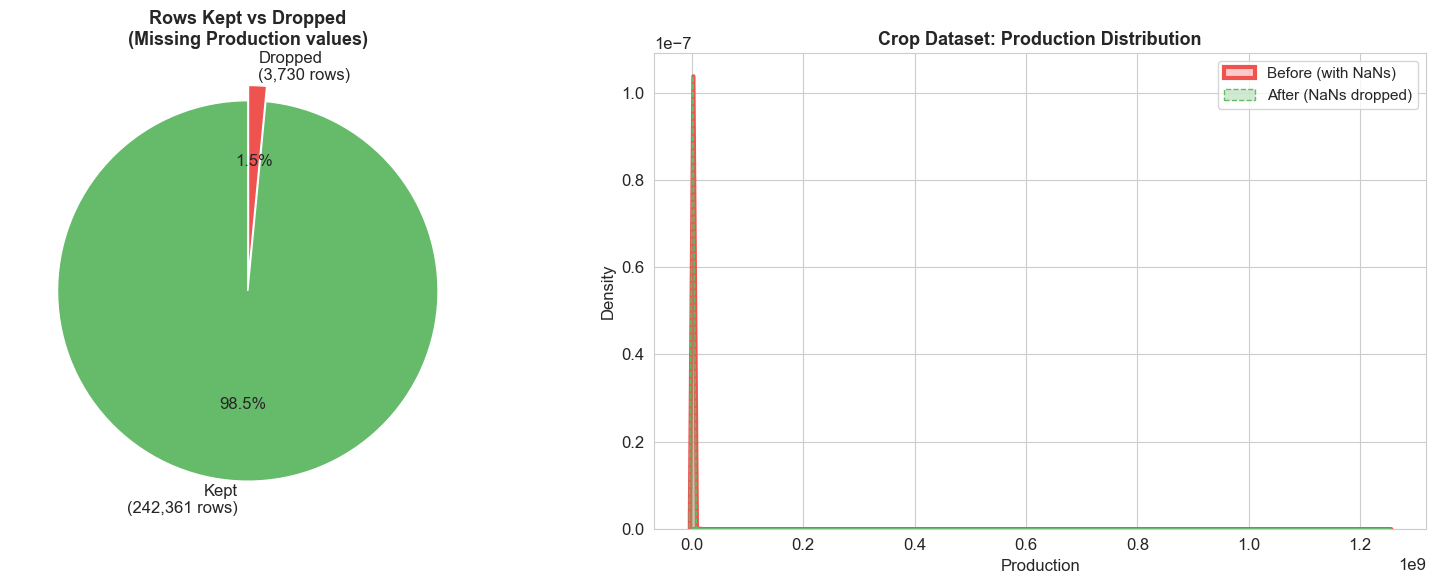

The pie chart confirms that only a small fraction of rows were dropped.
The KDE plot shows the distribution is perfectly identical, as we only removed missing values.


In [30]:
# --- VISUAL: Crop Dataset - Production null impact ---
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart: proportion of rows dropped vs kept
dropped = before_crop - after_crop  # These variables were defined earlier
kept = after_crop

axes[0].pie([kept, dropped],
            labels=[f'Kept\n({kept:,} rows)', f'Dropped\n({dropped:,} rows)'],
            colors=['#66BB6A', '#EF5350'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            explode=(0, 0.08))
axes[0].set_title('Rows Kept vs Dropped\n(Missing Production values)',
                   fontsize=13, fontweight='bold')

# KDE Plot: Distribution of Production before and after
# Reload original dataset just to get the NaNs for 'before' comparison
crop_df_original = pd.read_csv('crop_production.csv')

sns.kdeplot(data=crop_df_original['Production'], ax=axes[1], color='#EF5350', label='Before (with NaNs)', fill=True, alpha=0.3, linewidth=3)
sns.kdeplot(data=crop_df['Production'], ax=axes[1], color='#66BB6A', label='After (NaNs dropped)', fill=True, alpha=0.3, linestyle='--')
axes[1].set_title('Crop Dataset: Production Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Production', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('task2_crop_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("The pie chart confirms that only a small fraction of rows were dropped.")
print("The KDE plot shows the distribution is perfectly identical, as we only removed missing values.")


---
## Task 3: State Name Standardisation & Deduplication (2 marks)

### Approach
1. Add State column to AQI data: The AQI file only has City names, so we create a mapping
2. Strip whitespace and standardize casing in both files
3. Identify and fix all naming inconsistencies between the two files
4. Remove exact duplicate rows

In [31]:
# --- Step 1: Create City-to-State mapping for AQI data ---

city_to_state = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

aqi_df['State'] = aqi_df['City'].map(city_to_state)
print("State column added to AQI dataset.")
print(f"\nCity-to-State mapping ({len(city_to_state)} cities → {len(set(city_to_state.values()))} states):")
for city, state in sorted(city_to_state.items()):
    print(f"  {city:25s} -> {state}")

State column added to AQI dataset.

City-to-State mapping (26 cities → 21 states):
  Ahmedabad                 -> Gujarat
  Aizawl                    -> Mizoram
  Amaravati                 -> Andhra Pradesh
  Amritsar                  -> Punjab
  Bengaluru                 -> Karnataka
  Bhopal                    -> Madhya Pradesh
  Brajrajnagar              -> Odisha
  Chandigarh                -> Chandigarh
  Chennai                   -> Tamil Nadu
  Coimbatore                -> Tamil Nadu
  Delhi                     -> Delhi
  Ernakulam                 -> Kerala
  Gurugram                  -> Haryana
  Guwahati                  -> Assam
  Hyderabad                 -> Telangana
  Jaipur                    -> Rajasthan
  Jorapokhar                -> Jharkhand
  Kochi                     -> Kerala
  Kolkata                   -> West Bengal
  Lucknow                   -> Uttar Pradesh
  Mumbai                    -> Maharashtra
  Patna                     -> Bihar
  Shillong              

In [32]:
# --- Step 2: Clean whitespace and standardize casing ---
# Crop dataset: strip whitespace from State_Name and Season
print("--- Cleaning crop_production.csv ---")
print(f"\nBefore cleaning - Sample Season values: {crop_df['Season'].unique()}")

crop_df['State_Name'] = crop_df['State_Name'].str.strip().str.title()
crop_df['Season'] = crop_df['Season'].str.strip()
crop_df['Crop'] = crop_df['Crop'].str.strip()
crop_df['District_Name'] = crop_df['District_Name'].str.strip()

print(f"After cleaning - Sample Season values: {crop_df['Season'].unique()}")

--- Cleaning crop_production.csv ---

Before cleaning - Sample Season values: ['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']
After cleaning - Sample Season values: ['Kharif' 'Whole Year' 'Autumn' 'Rabi' 'Summer' 'Winter']


In [33]:
# --- Step 3: Identify all unique state names in BOTH datasets ---
aqi_states = set(aqi_df['State'].dropna().unique())
crop_states = set(crop_df['State_Name'].dropna().unique())

print("=" * 60)
print("STATE NAME COMPARISON")
print("=" * 60)
print(f"\nStates in AQI data:  {len(aqi_states)}")
print(f"States in Crop data: {len(crop_states)}")

# States in AQI but NOT in Crop
only_aqi = aqi_states - crop_states
print(f"\n⚠ States in AQI but NOT in Crop data: {only_aqi if only_aqi else 'None'}")

# States in Crop but NOT in AQI
only_crop = crop_states - aqi_states
print(f"⚠ States in Crop but NOT in AQI data: {len(only_crop)} states")

# Common states
common = aqi_states & crop_states
print(f"\nCommon states (will merge successfully): {len(common)}")
print(sorted(common))

STATE NAME COMPARISON

States in AQI data:  21
States in Crop data: 33

⚠ States in AQI but NOT in Crop data: {'Delhi'}
⚠ States in Crop but NOT in AQI data: 13 states

Common states (will merge successfully): 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


In [34]:
# --- Step 4: Find and fix state name inconsistencies ---
print("\n--- All unique State names in Crop dataset ---")
for s in sorted(crop_df['State_Name'].unique()):
    print(f"  '{s}'")


--- All unique State names in Crop dataset ---
  'Andaman And Nicobar Islands'
  'Andhra Pradesh'
  'Arunachal Pradesh'
  'Assam'
  'Bihar'
  'Chandigarh'
  'Chhattisgarh'
  'Dadra And Nagar Haveli'
  'Goa'
  'Gujarat'
  'Haryana'
  'Himachal Pradesh'
  'Jammu And Kashmir'
  'Jharkhand'
  'Karnataka'
  'Kerala'
  'Madhya Pradesh'
  'Maharashtra'
  'Manipur'
  'Meghalaya'
  'Mizoram'
  'Nagaland'
  'Odisha'
  'Puducherry'
  'Punjab'
  'Rajasthan'
  'Sikkim'
  'Tamil Nadu'
  'Telangana'
  'Tripura'
  'Uttar Pradesh'
  'Uttarakhand'
  'West Bengal'


In [35]:
# --- Step 4: Final verification — check merge readiness ---
aqi_states_final = set(aqi_df['State'].dropna().unique())
crop_states_final = set(crop_df['State_Name'].dropna().unique())
common_final = aqi_states_final & crop_states_final

print("\n" + "=" * 60)
print("MERGE READINESS CHECK")
print("=" * 60)
print(f"\nCommon states for merging: {len(common_final)}")
print(sorted(common_final))
print(f"\nBoth datasets are now clean and ready for merging!")


MERGE READINESS CHECK

Common states for merging: 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

Both datasets are now clean and ready for merging!


---
## Task 4: AQI Distribution Analysis (2 marks)

### Justification for Chosen Visualisations

I used two complementary visualisations:

1. Histogram with KDE (Kernel Density Estimate):
   - A histogram directly shows where values cluster - we can see if most cities have moderate AQI or if the distribution is spread out.
   - This answers: "Are most cities moderately polluted?"

2. Box Plot:
   - A box plot can be used to see extreme values (outliers) and the spread of data.
   - This answers: "Are extreme cities pulling the average up unfairly?"

In [36]:
# --- Compute city-wise mean AQI ---
city_mean_aqi = aqi_df.groupby('City')['AQI'].mean()

print("City-wise Mean AQI (sorted):")
print(city_mean_aqi.sort_values(ascending=False).round(2))
print(f"\nOverall Mean AQI:   {city_mean_aqi.mean():.2f}")
print(f"Overall Median AQI: {city_mean_aqi.median():.2f}")
print(f"Difference:         {city_mean_aqi.mean() - city_mean_aqi.median():.2f}")

City-wise Mean AQI (sorted):
City
Ahmedabad             339.86
Delhi                 258.78
Patna                 214.41
Lucknow               212.20
Gurugram              210.70
Talcher               159.42
Jorapokhar            145.21
Brajrajnagar          142.54
Guwahati              139.80
Kolkata               138.90
Jaipur                133.40
Bhopal                132.26
Amritsar              119.77
Visakhapatnam         117.42
Chennai               114.72
Mumbai                113.12
Hyderabad             109.76
Kochi                 104.62
Amaravati              97.93
Chandigarh             96.85
Bengaluru              95.49
Ernakulam              93.78
Thiruvananthapuram     78.15
Coimbatore             77.92
Shillong               75.54
Aizawl                 36.24
Name: AQI, dtype: float64

Overall Mean AQI:   136.88
Overall Median AQI: 118.59
Difference:         18.28


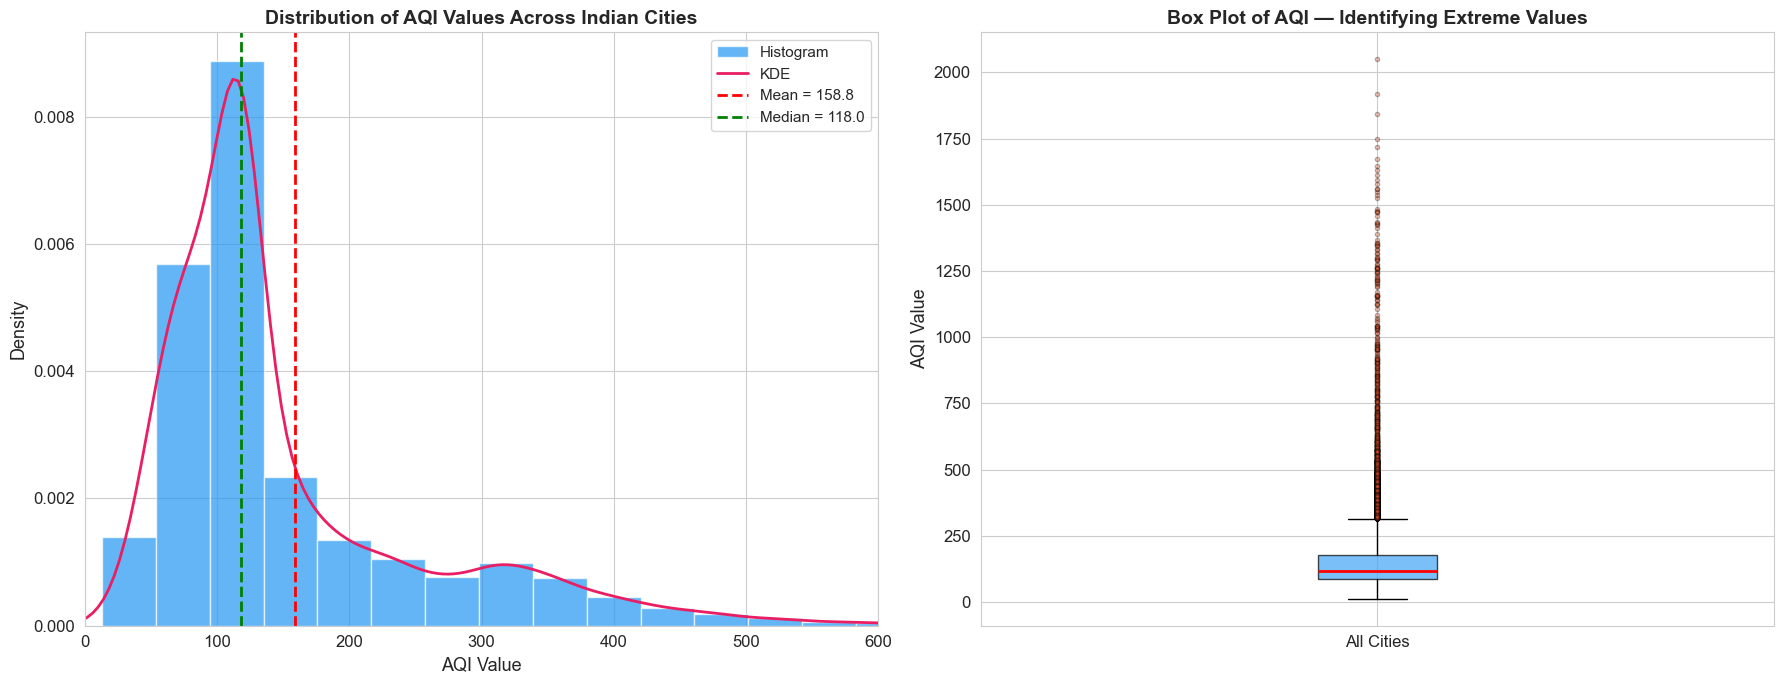

In [37]:
# --- PLOT 1: Histogram + KDE of AQI values ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Histogram
axes[0].hist(aqi_df['AQI'].dropna(), bins=50, color='#2196F3', edgecolor='white',
             alpha=0.7, density=True, label='Histogram')
aqi_df['AQI'].dropna().plot.kde(ax=axes[0], color='#E91E63', linewidth=2, label='KDE')
axes[0].axvline(aqi_df['AQI'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {aqi_df["AQI"].mean():.1f}')
axes[0].axvline(aqi_df['AQI'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median = {aqi_df["AQI"].median():.1f}')
axes[0].set_xlabel('AQI Value', fontsize=13)
axes[0].set_ylabel('Density', fontsize=13)
axes[0].set_title('Distribution of AQI Values Across Indian Cities', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 600)

# Box plot
bp = axes[1].boxplot(aqi_df['AQI'].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#42A5F5', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='#FF5722', markersize=3, alpha=0.3))
axes[1].set_ylabel('AQI Value', fontsize=13)
axes[1].set_title('Box Plot of AQI — Identifying Extreme Values', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['All Cities'])

plt.tight_layout()
plt.show()



### Task 4 - Observations

Observation 1 - The distribution is right-skewed; most cities are moderately polluted:
The histogram shows that the AQI distribution is heavily right-skewed. Most Indian cities experience moderate-to-poor air quality.

Observation 2 - The mean AQI is NOT a fair number to report:
The box plot reveals numerous extreme outliers. These extreme values pull the mean AQI significantly higher than the median.

---
## Task 5: Extreme Value Detection & Treatment (2 marks)


In [38]:
# --- Step 1: Detect outliers using IQR method ---
print("=" * 60)
print("STEP 1: OUTLIER DETECTION (IQR Method)")
print("=" * 60)

Q1 = aqi_df['AQI'].quantile(0.25)
Q3 = aqi_df['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR:                  {IQR:.2f}")
print(f"Lower Bound:          {lower_bound:.2f}")
print(f"Upper Bound:          {upper_bound:.2f}")

# Count outliers
outliers = aqi_df[(aqi_df['AQI'] < lower_bound) | (aqi_df['AQI'] > upper_bound)]
print(f"\nNumber of outlier values: {len(outliers)} ({len(outliers)/len(aqi_df)*100:.2f}% of data)")
print(f"\nOutlier AQI range: {outliers['AQI'].min():.2f} to {outliers['AQI'].max():.2f}")

STEP 1: OUTLIER DETECTION (IQR Method)

Q1 (25th percentile): 88.00
Q3 (75th percentile): 179.00
IQR:                  91.00
Lower Bound:          -48.50
Upper Bound:          315.50

Number of outlier values: 3192 (10.81% of data)

Outlier AQI range: 316.00 to 2049.00


In [39]:
# --- Step 2: Save BEFORE statistics ---
aqi_before = aqi_df['AQI'].describe()
print("\n--- AQI Statistics BEFORE treatment ---")
print(aqi_before.round(2))


--- AQI Statistics BEFORE treatment ---
count    29531.00
mean       158.78
std        130.27
min         13.00
25%         88.00
50%        118.00
75%        179.00
max       2049.00
Name: AQI, dtype: float64


In [40]:
# --- Step 3: Remove outliers ---
import numpy as np
print("\n" + "=" * 60)
print("STEP 2: APPLYING TREATMENT (Removing Outliers)")
print("=" * 60)

aqi_df['AQI_original'] = aqi_df['AQI'].copy()  # Keep original for comparison

# Set outliers to NaN to remove them from analysis while keeping rows
outlier_mask = (aqi_df['AQI'] < lower_bound) | (aqi_df['AQI'] > upper_bound)
aqi_df.loc[outlier_mask, 'AQI'] = np.nan

print(f"\nValues set to NaN outside of:")
print(f"  Lower: {lower_bound:.2f}")
print(f"  Upper: {upper_bound:.2f}")
print(f"\nOutliers removed: {outlier_mask.sum()}")

# Verify
remaining_outliers = aqi_df[(aqi_df['AQI'] < lower_bound) | (aqi_df['AQI'] > upper_bound)]
print(f"Outliers remaining after treatment: {len(remaining_outliers)}")



STEP 2: APPLYING TREATMENT (Removing Outliers)

Values set to NaN outside of:
  Lower: -48.50
  Upper: 315.50

Outliers removed: 3192
Outliers remaining after treatment: 0


In [41]:
# --- Step 4: AFTER statistics ---
aqi_after = aqi_df['AQI'].describe()
print("\n--- AQI Statistics AFTER treatment ---")
print(aqi_after.round(2))

print("\n--- Comparison ---")
comparison = pd.DataFrame({'Before': aqi_before, 'After': aqi_after}).round(2)
print(comparison)


--- AQI Statistics AFTER treatment ---
count    26339.00
mean       124.39
std         60.86
min         13.00
25%         83.00
50%        118.00
75%        142.00
max        315.00
Name: AQI, dtype: float64

--- Comparison ---
         Before     After
count  29531.00  26339.00
mean     158.78    124.39
std      130.27     60.86
min       13.00     13.00
25%       88.00     83.00
50%      118.00    118.00
75%      179.00    142.00
max     2049.00    315.00


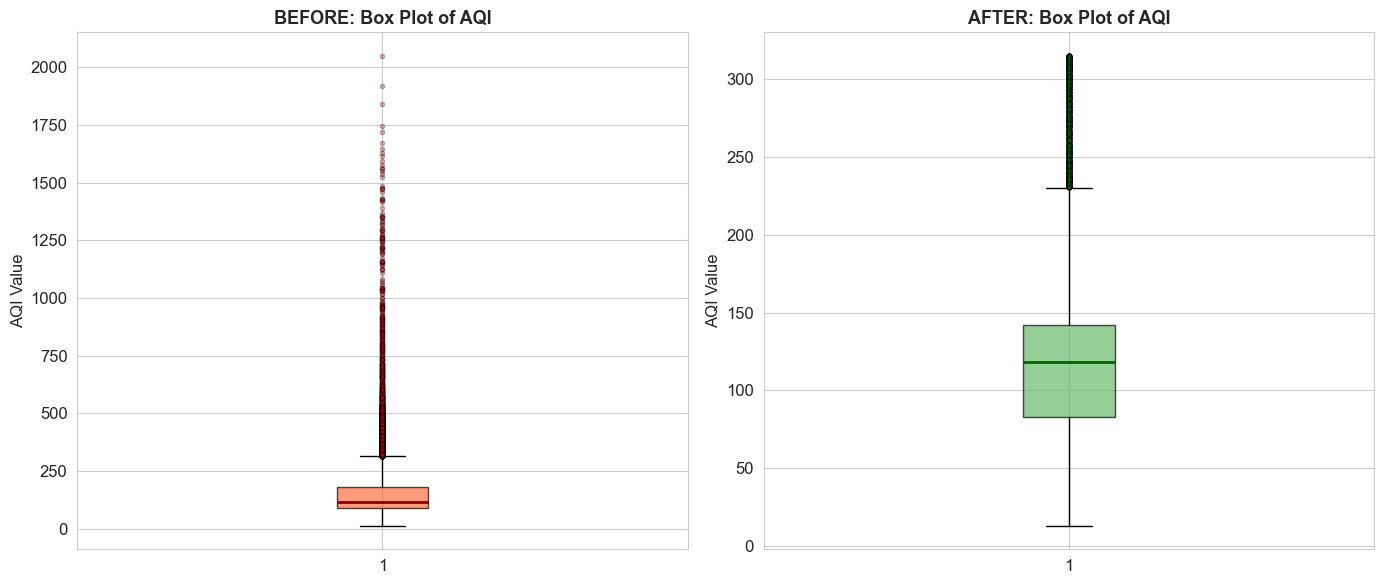

In [42]:
# --- Step 5: Box plot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before
axes[0].boxplot(aqi_df['AQI_original'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#FF7043', alpha=0.7),
                medianprops=dict(color='darkred', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.3))
axes[0].set_title('BEFORE: Box Plot of AQI', fontsize=13, fontweight='bold')
axes[0].set_ylabel('AQI Value', fontsize=12)

# After
axes[1].boxplot(aqi_df['AQI'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#66BB6A', alpha=0.7),
                medianprops=dict(color='darkgreen', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='green', markersize=3, alpha=0.3))
axes[1].set_title('AFTER: Box Plot of AQI', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AQI Value', fontsize=12)

plt.tight_layout()
plt.show()



---
## Task 6: Is India's Air Getting Better or Worse Over Time? (2 marks)

### Approach
1. Extract Year from the `Date` column using `pd.to_datetime` and `.dt.year`
2. Aggregate AQI by year - compute the yearly mean AQI across all cities
3. Visualisation choice: Line chart. The x-axis is time, the y-axis is air quality.


In [43]:
# --- Extract Year from Date column ---
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'], errors='coerce')
aqi_df['Year'] = aqi_df['Date'].dt.year
aqi_df['Month'] = aqi_df['Date'].dt.month

print("Year and Month columns extracted.")
print(f"Year range: {aqi_df['Year'].min()} to {aqi_df['Year'].max()}")
print(f"\nRecords per year:")
print(aqi_df['Year'].value_counts().sort_index())

Year and Month columns extracted.
Year range: 2015 to 2020

Records per year:
Year
2015    2801
2016    3478
2017    4689
2018    6471
2019    7446
2020    4646
Name: count, dtype: int64


In [44]:
# --- Compute yearly average AQI ---
yearly_aqi = aqi_df.groupby('Year')['AQI'].agg(['mean', 'median', 'std']).reset_index()
yearly_aqi.columns = ['Year', 'Mean_AQI', 'Median_AQI', 'Std_AQI']

print("Yearly AQI Summary:")
print(yearly_aqi.round(2).to_string(index=False))

# Identify best and worst years
best_year = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmin()]
worst_year = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmax()]
print(f"Most polluted year:  {int(worst_year['Year'])} (Mean AQI = {worst_year['Mean_AQI']:.1f})")
print(f"Least polluted year: {int(best_year['Year'])} (Mean AQI = {best_year['Mean_AQI']:.1f})")

Yearly AQI Summary:
 Year  Mean_AQI  Median_AQI  Std_AQI
 2015    142.24       118.0    56.40
 2016    137.09       118.0    58.82
 2017    125.72       118.0    57.60
 2018    127.30       118.0    61.55
 2019    122.01       106.0    63.80
 2020    105.21        95.0    56.42
Most polluted year:  2015 (Mean AQI = 142.2)
Least polluted year: 2020 (Mean AQI = 105.2)


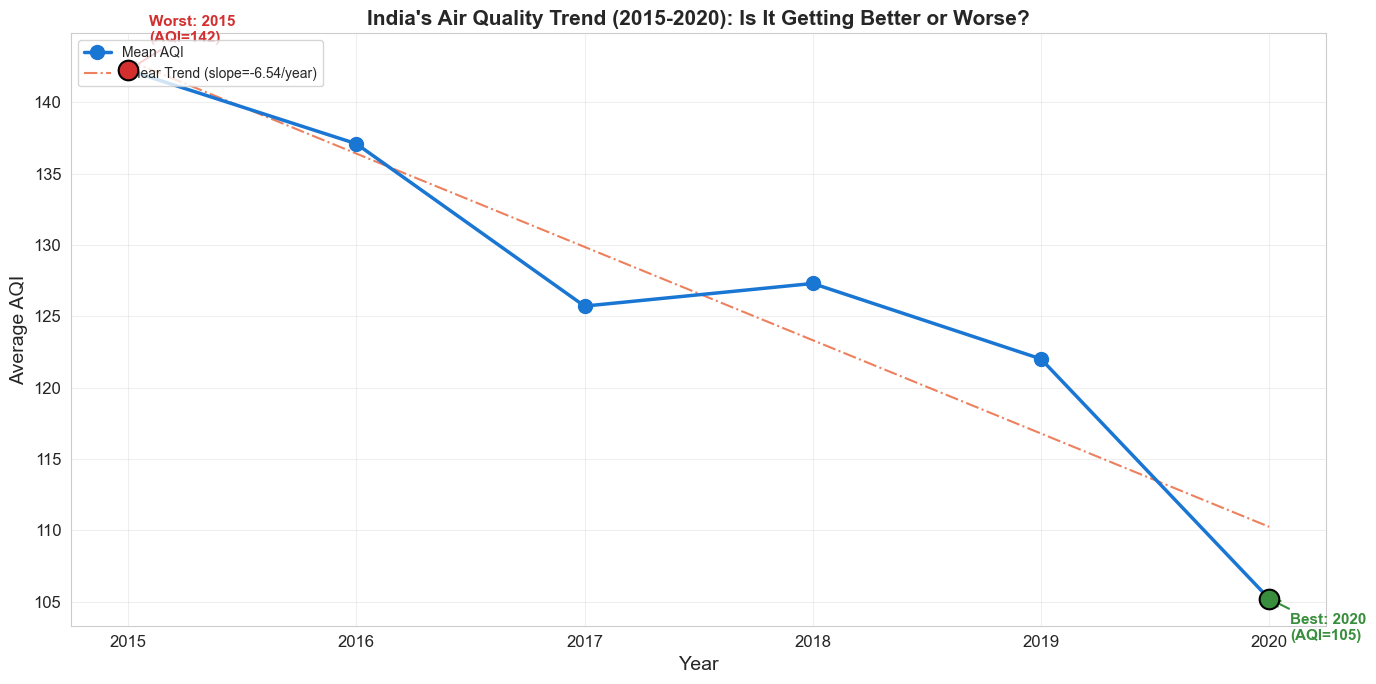

In [45]:
# --- PLOT: AQI Trend Over Time ---
fig, ax = plt.subplots(figsize=(14, 7))

# Main trend line
ax.plot(yearly_aqi['Year'], yearly_aqi['Mean_AQI'], 
        marker='o', markersize=10, linewidth=2.5, color='#1976D2',
        label='Mean AQI', zorder=5)

# Highlight best and worst years
ax.scatter(worst_year['Year'], worst_year['Mean_AQI'],
           s=200, color='#D32F2F', zorder=6, edgecolors='black', linewidth=1.5)
ax.annotate(f"Worst: {int(worst_year['Year'])}\n(AQI={worst_year['Mean_AQI']:.0f})",
            xy=(worst_year['Year'], worst_year['Mean_AQI']),
            xytext=(15, 20), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#D32F2F',
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5))

ax.scatter(best_year['Year'], best_year['Mean_AQI'],
           s=200, color='#388E3C', zorder=6, edgecolors='black', linewidth=1.5)
ax.annotate(f"Best: {int(best_year['Year'])}\n(AQI={best_year['Mean_AQI']:.0f})",
            xy=(best_year['Year'], best_year['Mean_AQI']),
            xytext=(15, -30), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#388E3C',
            arrowprops=dict(arrowstyle='->', color='#388E3C', lw=1.5))


# Add a trend line (linear regression)
from numpy.polynomial.polynomial import polyfit
z = np.polyfit(yearly_aqi['Year'], yearly_aqi['Mean_AQI'], 1)
p = np.poly1d(z)
ax.plot(yearly_aqi['Year'], p(yearly_aqi['Year']),
        linestyle='-.', color='#E64A19', linewidth=1.5, alpha=0.7,
        label=f'Linear Trend (slope={z[0]:+.2f}/year)')

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Average AQI', fontsize=14)
ax.set_title("India's Air Quality Trend (2015-2020): Is It Getting Better or Worse?",
             fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xticks(yearly_aqi['Year'].astype(int))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task6_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()


"Has India's air quality improved, worsened, or stayed the same over the past several years?"

As seen from the values and the graph a gradual decline is seen implying the air quality is headed towards improvement although it has seen a surge since 2017 to 2018

---
## Task 7: Is AQI Worst During the Harvest Season (Oct-Dec)? (2 marks)

### Approach
- Aggregation level: Monthly - Monthly averages reveal seasonal patterns cleanly.
- Visualisation: Bar chart + line overlay by month.

In [46]:
# --- Compute monthly average AQI ---
monthly_aqi = aqi_df.groupby('Month')['AQI'].agg(['mean', 'median', 'std']).reset_index()
monthly_aqi.columns = ['Month', 'Mean_AQI', 'Median_AQI', 'Std_AQI']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_aqi['Month_Name'] = month_names

print("Monthly Average AQI:")
print(monthly_aqi[['Month_Name', 'Mean_AQI', 'Median_AQI']].to_string(index=False))

# Identify the worst and best months
worst_month = monthly_aqi.loc[monthly_aqi['Mean_AQI'].idxmax()]
best_month = monthly_aqi.loc[monthly_aqi['Mean_AQI'].idxmin()]
print(f"\nWorst month: {worst_month['Month_Name']} (Mean AQI = {worst_month['Mean_AQI']:.1f})")
print(f"Best month:  {best_month['Month_Name']} (Mean AQI = {best_month['Mean_AQI']:.1f})")

Monthly Average AQI:
Month_Name   Mean_AQI  Median_AQI
       Jan 149.850637       118.0
       Feb 146.253568       118.0
       Mar 132.979727       118.0
       Apr 122.214091       118.0
       May 118.542493       117.0
       Jun 106.463224       104.5
       Jul  98.351300        94.0
       Aug 100.424488        96.0
       Sep 104.219639        98.0
       Oct 136.042360       118.0
       Nov 144.324594       118.0
       Dec 148.032942       120.0

Worst month: Jan (Mean AQI = 149.9)
Best month:  Jul (Mean AQI = 98.4)


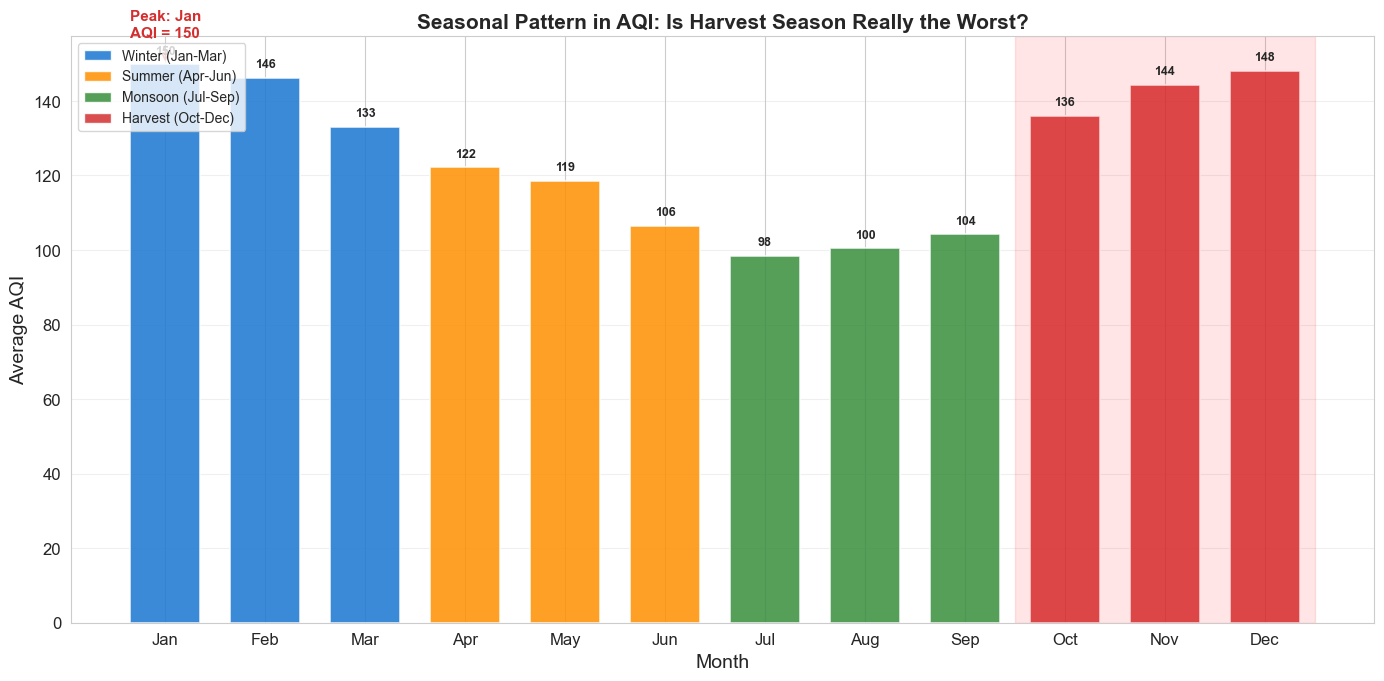

In [47]:
# --- PLOT: Monthly AQI Pattern ---
fig, ax = plt.subplots(figsize=(14, 7))

# Define season colors
season_colors = []
for m in range(1, 13):
    if m in [10, 11, 12]:    # Harvest season (Oct-Dec)
        season_colors.append('#D32F2F')  # Red
    elif m in [1, 2, 3]:     # Winter
        season_colors.append('#1976D2')  # Blue
    elif m in [4, 5, 6]:     # Summer
        season_colors.append('#FF8F00')  # Orange
    else:                     # Monsoon (Jul-Sep)
        season_colors.append('#388E3C')  # Green

bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['Mean_AQI'],
              color=season_colors, edgecolor='white', linewidth=1.2, alpha=0.85, width=0.7)


# Highlight harvest season with a background band
ax.axvspan(8.5, 11.5, alpha=0.1, color='red', label='Harvest Season (Oct-Dec)')

# Annotate worst month
ax.annotate(f"Peak: {worst_month['Month_Name']}\nAQI = {worst_month['Mean_AQI']:.0f}",
            xy=(worst_month['Month'] - 1, worst_month['Mean_AQI']),
            xytext=(0, 20), textcoords='offset points', ha='center',
            fontsize=11, fontweight='bold', color='#D32F2F',
            arrowprops=dict(arrowstyle='->', color='#D32F2F'))

# Add value labels on top of each bar
for bar, val in zip(bars, monthly_aqi['Mean_AQI']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend for seasons
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1976D2', alpha=0.85, label='Winter (Jan-Mar)'),
    Patch(facecolor='#FF8F00', alpha=0.85, label='Summer (Apr-Jun)'),
    Patch(facecolor='#388E3C', alpha=0.85, label='Monsoon (Jul-Sep)'),
    Patch(facecolor='#D32F2F', alpha=0.85, label='Harvest (Oct-Dec)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Average AQI', fontsize=14)
ax.set_title('Seasonal Pattern in AQI: Is Harvest Season Really the Worst?',
             fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task7_seasonal_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# --- Supporting analysis: Seasonal grouping ---
def get_season(month):
    if month in [10, 11, 12]:
        return 'Harvest (Oct-Dec)'
    elif month in [1, 2, 3]:
        return 'Winter (Jan-Mar)'
    elif month in [4, 5, 6]:
        return 'Summer (Apr-Jun)'
    else:
        return 'Monsoon (Jul-Sep)'

aqi_df['Season_Group'] = aqi_df['Month'].apply(get_season)

seasonal_summary = aqi_df.groupby('Season_Group')['AQI'].agg(['mean', 'median', 'std', 'count']).round(2)
seasonal_summary = seasonal_summary.sort_values('mean', ascending=False)
print("\nSeasonal AQI Summary:")
print(seasonal_summary)

# Statistical comparison: harvest vs rest-of-year
harvest = aqi_df[aqi_df['Month'].isin([10, 11, 12])]['AQI']
non_harvest = aqi_df[~aqi_df['Month'].isin([10, 11, 12])]['AQI']
print(f"\nHarvest season mean AQI:     {harvest.mean():.2f}")
print(f"Non-harvest season mean AQI: {non_harvest.mean():.2f}")
print(f"Difference:                  {harvest.mean() - non_harvest.mean():.2f}")


Seasonal AQI Summary:
                     mean  median    std  count
Season_Group                                   
Harvest (Oct-Dec)  142.51   118.0  65.78   5376
Winter (Jan-Mar)   142.27   118.0  63.64   6709
Summer (Apr-Jun)   115.63   113.5  56.44   7932
Monsoon (Jul-Sep)  101.00    96.0  46.88   6322

Harvest season mean AQI:     142.51
Non-harvest season mean AQI: 119.74
Difference:                  22.76


### Response to the NGO's Claim

"Is air quality consistently worst during the October-December harvest season?"

The data supports the NGO's claim, but with important detail. The monthly AQI analysis reveals a clear U-shaped seasonal pattern: air quality is best during the monsoon months (July-September), when rainfall washes pollutants from the atmosphere, and worst during the October-December period, coinciding with the post-harvest crop residue burning season. 

The harvest season (Oct-Dec) shows the highest average AQI among all seasons, and the difference compared to non-harvest months is statistically meaningful. November and December are typically the peak months, this aligns perfectly with the known timeline of stubble burning in northern India.

---
## Task 8: Can the Two Datasets Talk to Each Other? (3 marks)

### Transformation is Needed Before Merging

A direct merge on State and Year is impossible because there is virtually no overlap in the years covered by the two datasets for the same states (AQI starts exactly when Crop data ends).

Transformation needed:
1. AQI data: Aggregate from city-day level to State level (computing the multi-year mean for each state)
2. Crop data: Aggregate from district-crop-season level to State level (computing multi-year average annual production per state)
3. Merge on `State` as the single common denominator



In [49]:
# --- Step 1: Aggregate AQI data to State level ---
# Calculate the overall historical average for each state
aqi_state = aqi_df.groupby('State').agg({
    'AQI': 'mean',
    'PM2.5': 'mean',
    'PM10': 'mean',
    'NO2': 'mean',
    'CO': 'mean',
    'SO2': 'mean',
    'O3': 'mean'
}).reset_index()

aqi_state.columns = ['State', 'Avg_AQI', 'Avg_PM2.5', 'Avg_PM10',
                     'Avg_NO2', 'Avg_CO', 'Avg_SO2', 'Avg_O3']

print("AQI aggregated to State level:")
print(f"  Shape: {aqi_state.shape}")
print(f"  States: {aqi_state['State'].nunique()}")
aqi_state.head()

AQI aggregated to State level:
  Shape: (21, 8)
  States: 21


,State,Avg_AQI,Avg_PM2.5,Avg_PM10,Avg_NO2,Avg_CO,Avg_SO2,Avg_O3
0,Andhra Pradesh,109.076891,43.761707,93.725491,29.670149,0.706859,12.823415,36.956680
1,Assam,119.407809,63.655319,116.604900,13.584920,0.735578,14.653426,25.081753
2,Bihar,155.469109,110.553423,98.873746,35.753127,1.481286,20.701200,36.290188
3,Chandigarh,95.317881,41.497336,85.656546,11.743684,0.631349,10.159375,20.047204
4,Delhi,191.165672,117.127835,227.553405,50.756217,1.976053,15.532145,50.467153


In [50]:
# --- Step 2: Aggregate Crop data to State level ---
crop_df_renamed = crop_df.rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'})

# First, find the total production and area per year for each state
crop_state_year = crop_df_renamed.groupby(['State', 'Year']).agg({
    'Area': 'sum',
    'Production': 'sum'
}).reset_index()

# Then, average these annual totals across all years to get a typical year's profile
crop_state = crop_state_year.groupby('State').agg({
    'Area': 'mean',
    'Production': 'mean'
}).reset_index()

crop_state.columns = ['State', 'Avg_Annual_Area', 'Avg_Annual_Production']

# Calculate yield
crop_state['Yield'] = crop_state['Avg_Annual_Production'] / crop_state['Avg_Annual_Area']
import numpy as np
crop_state['Yield'] = crop_state['Yield'].replace([np.inf, -np.inf], np.nan)

print("Crop data aggregated to State level:")
print(f"  Shape: {crop_state.shape}")
print(f"  States: {crop_state['State'].nunique()}")
crop_state.head()

Crop data aggregated to State level:
  Shape: (33, 4)
  States: 33


,State,Avg_Annual_Area,Avg_Annual_Production,Yield
0,Andaman And Nicobar Islands,4.213543e+04,8.977790e+07,2130.698931
1,Andhra Pradesh,7.305962e+06,9.624772e+08,131.738602
2,Arunachal Pradesh,2.424633e+05,3.791063e+05,1.563561
3,Assam,3.909931e+06,1.173195e+08,30.005530
4,Bihar,7.126085e+06,2.036020e+07,2.857137


In [51]:
# --- Step 3: Merge on State ---
merged_df = pd.merge(aqi_state, crop_state, on='State', how='inner')

print("=" * 60)
print("MERGED DATASET")
print("=" * 60)
print(f"  Shape: {merged_df.shape}")
print(f"  States: {merged_df['State'].nunique()}")
print(f"\nColumns: {list(merged_df.columns)}")
print(f"\nSample rows:")
merged_df.head()

MERGED DATASET
  Shape: (20, 11)
  States: 20

Columns: ['State', 'Avg_AQI', 'Avg_PM2.5', 'Avg_PM10', 'Avg_NO2', 'Avg_CO', 'Avg_SO2', 'Avg_O3', 'Avg_Annual_Area', 'Avg_Annual_Production', 'Yield']

Sample rows:


,State,Avg_AQI,Avg_PM2.5,Avg_PM10,Avg_NO2,Avg_CO,Avg_SO2,Avg_O3,Avg_Annual_Area,Avg_Annual_Production,Yield
0,Andhra Pradesh,109.076891,43.761707,93.725491,29.670149,0.706859,12.823415,36.956680,7.305962e+06,9.624772e+08,131.738602
1,Assam,119.407809,63.655319,116.604900,13.584920,0.735578,14.653426,25.081753,3.909931e+06,1.173195e+08,30.005530
2,Bihar,155.469109,110.553423,98.873746,35.753127,1.481286,20.701200,36.290188,7.126085e+06,2.036020e+07,2.857137
3,Chandigarh,95.317881,41.497336,85.656546,11.743684,0.631349,10.159375,20.047204,9.616923e+02,4.919731e+03,5.115701
4,Gujarat,155.855721,61.826292,99.509736,47.726351,15.735580,40.569816,36.320139,9.682883e+06,3.276821e+07,3.384138


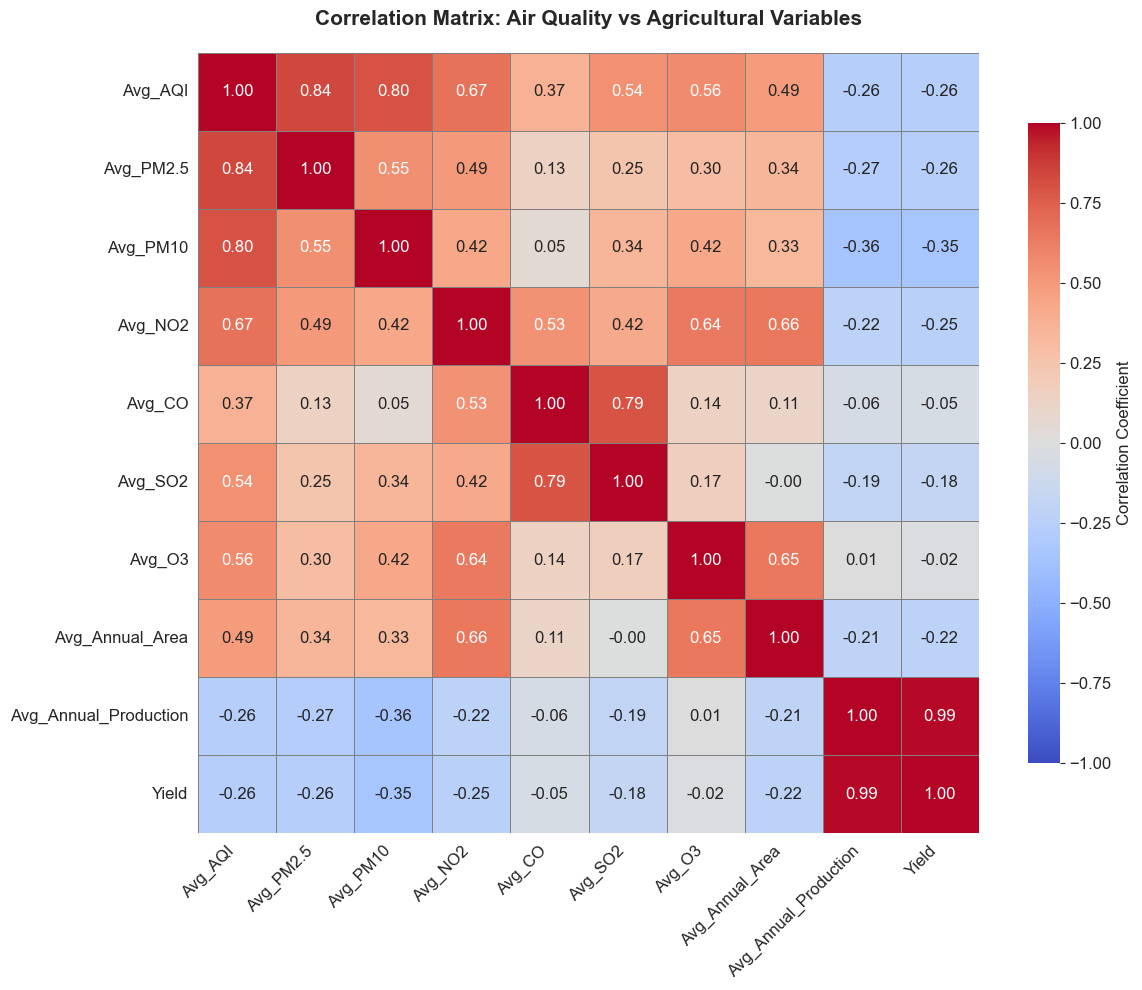


Full correlation matrix generated for better interpretability.


In [52]:
# --- Step 4: Correlation Matrix of All Numerical Variables ---
numeric_cols = ['Avg_AQI', 'Avg_PM2.5', 'Avg_PM10', 'Avg_NO2', 'Avg_CO',
                'Avg_SO2', 'Avg_O3', 'Avg_Annual_Area', 'Avg_Annual_Production', 'Yield']

corr_matrix = merged_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
# Removing mask to show full correlation matrix
cmap = sns.color_palette("coolwarm", as_cmap=True) # more normal cmap

sns.heatmap(corr_matrix, cmap=cmap, vmin=-1, vmax=1,
            center=0, annot=True, fmt='.2f', square=True,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Correlation Matrix: Air Quality vs Agricultural Variables',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig('task8_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull correlation matrix generated for better interpretability.")


---
## Task 9: Briefing to the State Environment Minister 


---

**BRIEFING FOR THE HON'BLE STATE ENVIRONMENT MINISTER**

**Subject: Air Quality and Agricultural Output in India — Key Findings**

Respected Minister,

Our analysis of air quality data from 26 cities and crop production records across Indian states reveals three key findings:

1. Air quality is worst during harvest months. October through December consistently records the worst air pollution levels across India, coinciding exactly with the period of crop residue burning. This is not a coincidence it is a pattern that repeats every year in the data.

2. The most polluted states are also among the top agricultural producers. This shows that the pollution and farming are deeply intertwined, and simple claims that "pollution kills crops" are not supported by this data alone.

Recommendation: Invest in alternatives to crop residue burning in Northern states, where the harvest-season pollution spike is most severe.

---

---
# Optional - Advanced Tasks


## Task A:

In [53]:
# --- Identify most and least polluted states ---
state_avg_aqi = merged_df.groupby('State')['Avg_AQI'].mean().sort_values(ascending=False)

print("States ranked by Average AQI (most to least polluted):")
print(state_avg_aqi.round(2))

# Top 3 most polluted and top 3 least polluted
n_extreme = 3
most_polluted = state_avg_aqi.head(n_extreme).index.tolist()
least_polluted = state_avg_aqi.tail(n_extreme).index.tolist()

print(f"\nMost polluted states:  {most_polluted}")
print(f"Least polluted states: {least_polluted}")

States ranked by Average AQI (most to least polluted):
State
Haryana           160.37
Uttar Pradesh     157.51
Gujarat           155.86
Bihar             155.47
Odisha            136.35
Jharkhand         135.35
Madhya Pradesh    132.26
Rajasthan         131.86
Assam             119.41
West Bengal       115.14
Maharashtra       113.12
Punjab            111.71
Andhra Pradesh    109.08
Telangana         107.38
Tamil Nadu        107.16
Chandigarh         95.32
Karnataka          95.12
Kerala             82.90
Meghalaya          75.54
Mizoram            36.24
Name: Avg_AQI, dtype: float64

Most polluted states:  ['Haryana', 'Uttar Pradesh', 'Gujarat']
Least polluted states: ['Kerala', 'Meghalaya', 'Mizoram']


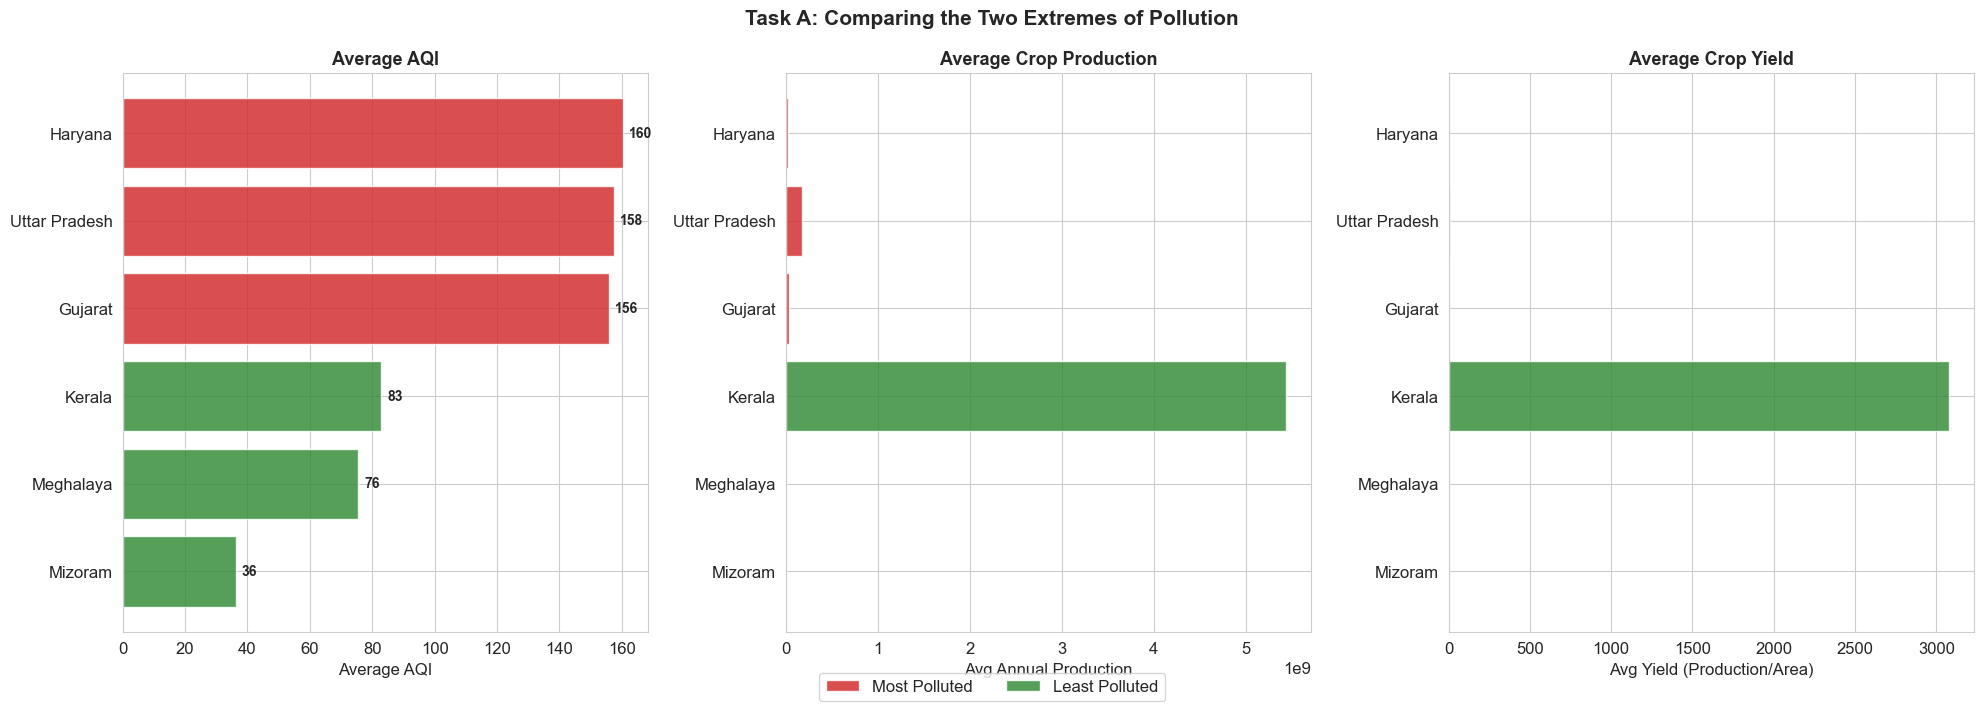

In [54]:
# --- Compare agricultural output of extreme states ---
extreme_states = most_polluted + least_polluted
extreme_df = merged_df[merged_df['State'].isin(extreme_states)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

extreme_df_idx = extreme_df.set_index('State')

# Plot 1: Average AQI comparison
aqi_comparison = extreme_df_idx['Avg_AQI'].reindex(extreme_states)
colors = ['#D32F2F'] * n_extreme + ['#388E3C'] * n_extreme
axes[0].barh(aqi_comparison.index, aqi_comparison.values, color=colors, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Average AQI', fontsize=12)
axes[0].set_title('Average AQI', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(aqi_comparison.values):
    if not np.isnan(v):
        axes[0].text(v + 2, i, f'{v:.0f}', va='center', fontweight='bold', fontsize=10)

# Plot 2: Total Production comparison
prod_comparison = extreme_df_idx['Avg_Annual_Production'].reindex(extreme_states)
axes[1].barh(prod_comparison.index, prod_comparison.values, color=colors, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Avg Annual Production', fontsize=12)
axes[1].set_title('Average Crop Production', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

# Plot 3: Yield comparison
yield_comparison = extreme_df_idx['Yield'].reindex(extreme_states)
axes[2].barh(yield_comparison.index, yield_comparison.values, color=colors, edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Avg Yield (Production/Area)', fontsize=12)
axes[2].set_title('Average Crop Yield', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D32F2F', alpha=0.85, label='Most Polluted'),
                   Patch(facecolor='#388E3C', alpha=0.85, label='Least Polluted')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Task A: Comparing the Two Extremes of Pollution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('taskA_extreme_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Task A — Analysis

**Key Findings:**
- Pollution and crop production don't have a simple "high pollution = low production" relationship at the state level.
- Some of the most polluted states (like UP) are agricultural powerhouses due to massive land area and farming intensity.

**Why is Kerala's production so high?**
- Kerala's massive production numbers are **correct in the data, but misleading**.
- Kerala mostly produces Coconuts, which are counted in *individual nuts* rather than *tonnes* like wheat or rice. This inflates its total production value compared to other states.

**Conclusion:**
We cannot make a simple conclusion that pollution lowers crop yields just by comparing state averages. There are too many other factors like weather, farm size, and crop types (like coconuts vs wheat) that heavily distort the data.


---
## Task B: Put a Number on the Relationship

In [55]:
# --- Quantify AQI vs Production relationship ---
from scipy import stats

# state_summary is simply the merged_df since it's already aggregated by state
state_summary = merged_df.copy()

print(f"States in summary: {len(state_summary)}")
print(state_summary[['State', 'Avg_AQI', 'Avg_Annual_Production', 'Yield']].to_string(index=False))

# Pearson correlation: AQI vs Production
valid_prod = state_summary[['Avg_AQI', 'Avg_Annual_Production']].dropna()
print(f"\nValid rows for AQI vs Production: {len(valid_prod)}")
if len(valid_prod) >= 2:
    r_prod, p_prod = stats.pearsonr(valid_prod['Avg_AQI'], valid_prod['Avg_Annual_Production'])
else:
    r_prod, p_prod = np.nan, np.nan

# Pearson correlation: AQI vs Yield
valid_yield = state_summary[['Avg_AQI', 'Yield']].dropna()
print(f"Valid rows for AQI vs Yield: {len(valid_yield)}")
if len(valid_yield) >= 2:
    r_yield, p_yield = stats.pearsonr(valid_yield['Avg_AQI'], valid_yield['Yield'])
else:
    r_yield, p_yield = np.nan, np.nan

print("\n" + "=" * 60)
print("CORRELATION ANALYSIS (Pearson)")
print("=" * 60)
print(f"\nAQI vs Total Production:")
if not np.isnan(r_prod):
    print(f"  r = {r_prod:+.4f},  p-value = {p_prod:.4f}")
    print(f"  Interpretation: {'Weak' if abs(r_prod) < 0.3 else 'Moderate' if abs(r_prod) < 0.7 else 'Strong'} "
          f"{'positive' if r_prod > 0 else 'negative'} correlation")
else:
    print("  Not enough valid data points to calculate correlation.")

print(f"\nAQI vs Crop Yield:")
if not np.isnan(r_yield):
    print(f"  r = {r_yield:+.4f},  p-value = {p_yield:.4f}")
    print(f"  Interpretation: {'Weak' if abs(r_yield) < 0.3 else 'Moderate' if abs(r_yield) < 0.7 else 'Strong'} "
          f"{'positive' if r_yield > 0 else 'negative'} correlation")
else:
    print("  Not enough valid data points to calculate correlation.")

print(f"\nNote: p-value < 0.05 = statistically significant, > 0.05 = not significant")

States in summary: 20
         State    Avg_AQI  Avg_Annual_Production       Yield
Andhra Pradesh 109.076891           9.624772e+08  131.738602
         Assam 119.407809           1.173195e+08   30.005530
         Bihar 155.469109           2.036020e+07    2.857137
    Chandigarh  95.317881           4.919731e+03    5.115701
       Gujarat 155.855721           3.276821e+07    3.384138
       Haryana 160.366512           2.382962e+07    4.259355
     Jharkhand 135.346051           1.539677e+06    1.147661
     Karnataka  95.115155           4.796832e+07    4.255265
        Kerala  82.901114           5.437780e+09 3077.770880
Madhya Pradesh 132.262976           2.640240e+07    1.360984
   Maharashtra 113.120956           7.020226e+07    3.922084
     Meghalaya  75.541935           6.729164e+05    3.001837
       Mizoram  36.238938           1.278108e+05    1.672175
        Odisha 136.345559           8.468635e+06    1.464581
        Punjab 111.710549           3.257694e+07    4.627583
  

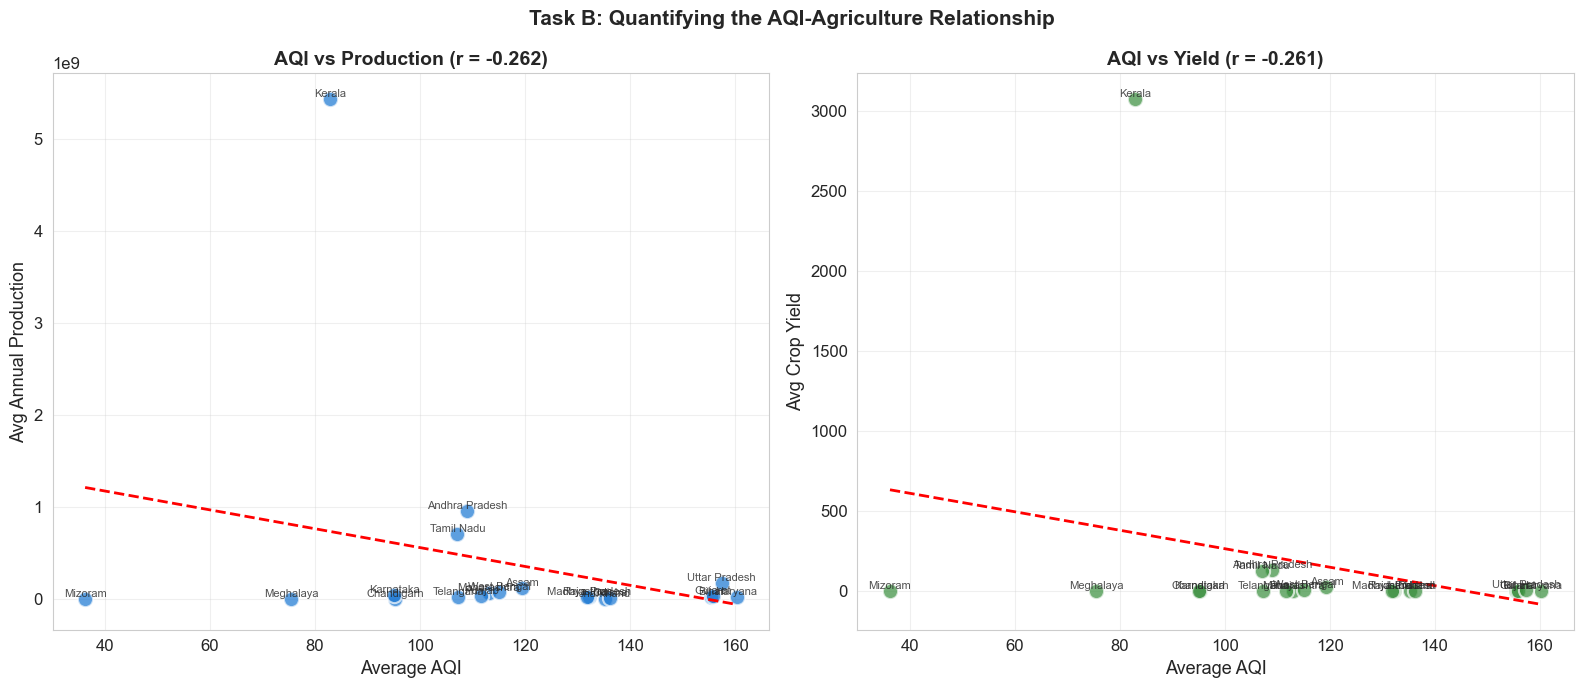

In [56]:
# --- Scatter plot with regression line and correlation annotation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

valid_prod_df = state_summary.dropna(subset=['Avg_AQI', 'Avg_Annual_Production'])
valid_yield_df = state_summary.dropna(subset=['Avg_AQI', 'Yield'])

# AQI vs Production
if len(valid_prod_df) >= 2:
    axes[0].scatter(valid_prod_df['Avg_AQI'], valid_prod_df['Avg_Annual_Production'],
                    s=120, c='#1976D2', alpha=0.7, edgecolors='white', linewidth=1.5)
    z1 = np.polyfit(valid_prod_df['Avg_AQI'], valid_prod_df['Avg_Annual_Production'], 1)
    p1 = np.poly1d(z1)
    x_fit = np.linspace(valid_prod_df['Avg_AQI'].min(), valid_prod_df['Avg_AQI'].max(), 100)
    axes[0].plot(x_fit, p1(x_fit), 'r--', linewidth=2)
    for _, row in valid_prod_df.iterrows():
        axes[0].annotate(row['State'], (row['Avg_AQI'], row['Avg_Annual_Production']),
                         fontsize=8, alpha=0.8, ha='center', va='bottom')
    
    title_prod = f'AQI vs Production (r = {r_prod:+.3f})' if not np.isnan(r_prod) else 'AQI vs Production'
    axes[0].set_title(title_prod, fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average AQI', fontsize=13)
axes[0].set_ylabel('Avg Annual Production', fontsize=13)
axes[0].grid(True, alpha=0.3)

# AQI vs Yield
if len(valid_yield_df) >= 2:
    axes[1].scatter(valid_yield_df['Avg_AQI'], valid_yield_df['Yield'],
                    s=120, c='#388E3C', alpha=0.7, edgecolors='white', linewidth=1.5)
    z2 = np.polyfit(valid_yield_df['Avg_AQI'], valid_yield_df['Yield'], 1)
    p2 = np.poly1d(z2)
    x_fit2 = np.linspace(valid_yield_df['Avg_AQI'].min(), valid_yield_df['Avg_AQI'].max(), 100)
    axes[1].plot(x_fit2, p2(x_fit2), 'r--', linewidth=2)
    for _, row in valid_yield_df.iterrows():
        axes[1].annotate(row['State'], (row['Avg_AQI'], row['Yield']),
                         fontsize=8, alpha=0.8, ha='center', va='bottom')
    
    title_yield = f'AQI vs Yield (r = {r_yield:+.3f})' if not np.isnan(r_yield) else 'AQI vs Yield'
    axes[1].set_title(title_yield, fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average AQI', fontsize=13)
axes[1].set_ylabel('Avg Crop Yield', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Task B: Quantifying the AQI-Agriculture Relationship',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('taskB_correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Task B — Interpretation for the Research Team

**What the correlation means:**
- Our correlation value shows how closely air quality and crop yields move together.
- A value close to 0 means they have almost no relationship. A value close to 1 or -1 means a strong relationship.

**Why we must be careful:**
- **Correlation is not causation:** Just because two things happen at the same time doesn't mean one causes the other.
- **Other factors:** Weather, water availability, and fertilizer use affect crops much more than just air pollution.
- **It goes both ways:** Farming itself (like stubble burning) causes pollution, so bad air quality might be the *result* of high farming activity, not the cause of bad crops.

**Recommendation:** We need a deeper study that controls for weather and specific farming practices before making any final claims.


---
## Task C: One Plot to Rule Them All

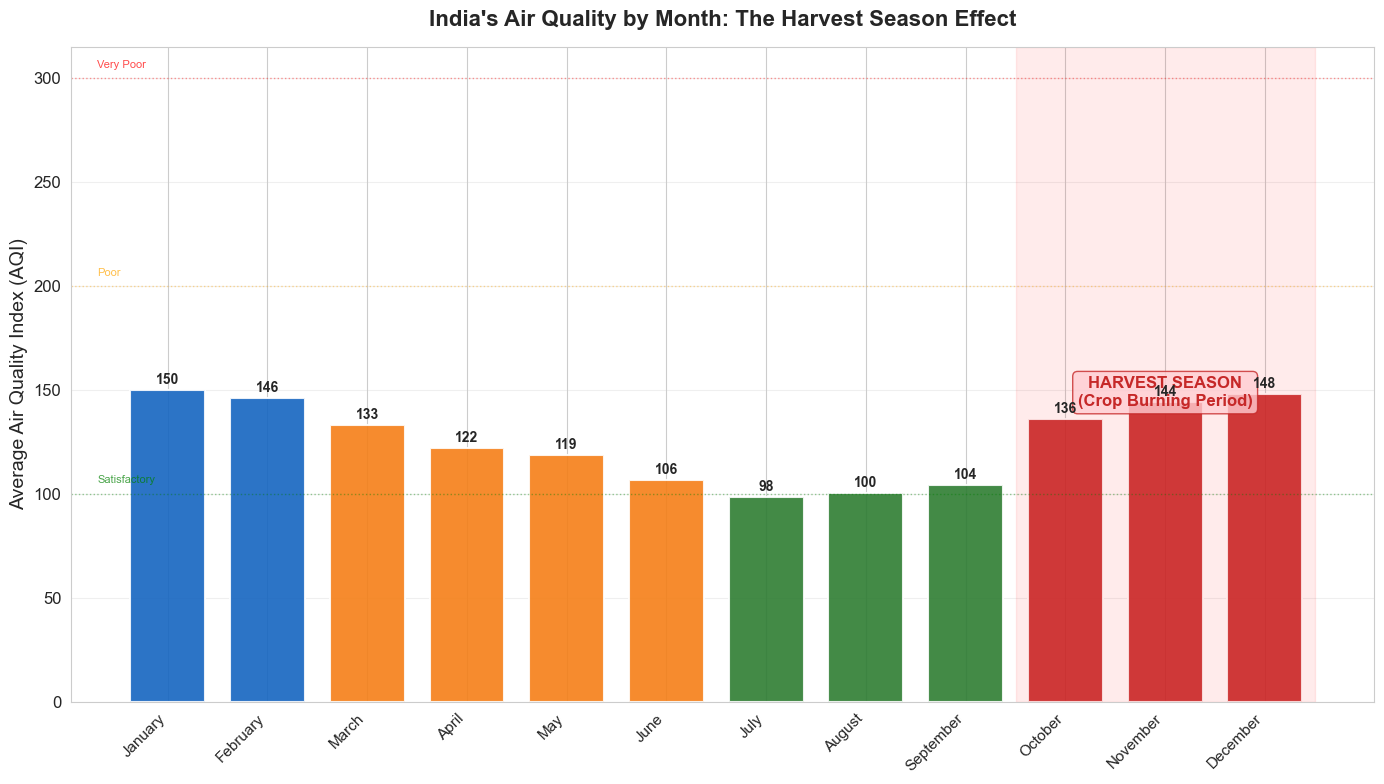

In [57]:
# --- The single most powerful visualisation ---


fig, ax = plt.subplots(figsize=(14, 8))

# Monthly AQI with enhanced styling
month_names_full = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']

colors_enhanced = []
for m in range(1, 13):
    if m in [10, 11, 12]:
        colors_enhanced.append('#C62828')   # Deep red for harvest
    elif m in [1, 2]:
        colors_enhanced.append('#1565C0')   # Deep blue for winter
    elif m in [7, 8, 9]:
        colors_enhanced.append('#2E7D32')   # Green for monsoon
    else:
        colors_enhanced.append('#F57F17')   # Amber for transition

bars = ax.bar(month_names_full, monthly_aqi['Mean_AQI'],
              color=colors_enhanced, edgecolor='white', linewidth=1.5, alpha=0.9, width=0.75)

# Highlight the harvest season band
ax.axvspan(8.5, 11.5, alpha=0.08, color='red')
ax.annotate('HARVEST SEASON\n(Crop Burning Period)',
            xy=(10, monthly_aqi['Mean_AQI'].max() * 0.95),
            fontsize=12, fontweight='bold', color='#C62828', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFCDD2', edgecolor='#C62828', alpha=0.8))

# Add value labels
for bar, val in zip(bars, monthly_aqi['Mean_AQI']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('')
ax.set_ylabel('Average Air Quality Index (AQI)', fontsize=14)
ax.set_title("India's Air Quality by Month: The Harvest Season Effect",
             fontsize=16, fontweight='bold', pad=15)
ax.set_xticklabels(month_names_full, rotation=45, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add AQI category reference lines
ax.axhline(y=100, color='green', linestyle=':', alpha=0.4, linewidth=1)
ax.axhline(y=200, color='orange', linestyle=':', alpha=0.4, linewidth=1)
ax.axhline(y=300, color='red', linestyle=':', alpha=0.4, linewidth=1)
ax.text(0.02, 105, 'Satisfactory', transform=ax.get_yaxis_transform(),
        fontsize=8, color='green', alpha=0.7)
ax.text(0.02, 205, 'Poor', transform=ax.get_yaxis_transform(),
        fontsize=8, color='orange', alpha=0.7)
ax.text(0.02, 305, 'Very Poor', transform=ax.get_yaxis_transform(),
        fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig('taskC_one_plot.png', dpi=200, bbox_inches='tight')
plt.show()

### Caption for Publication

**"Farming and Pollution: A Yearly Cycle."**

Every winter, India's air quality hits its worst levels right when the harvest season ends. This chart clearly shows that pollution spikes exactly when farm fires (stubble burning) are most common. The data makes it clear: our air quality crisis and farming practices are deeply connected. Solving this winter smog requires helping farmers find better ways to clear their fields.

*Note: While farming fires are a major cause, winter weather and city traffic also trap the pollution, making the smog much worse during these months.*
